In [1]:
import pandas as pd
ben_df= pd.read_csv("../data/raw/10_benchmark_indices.csv")
ben_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [2]:
ben_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [3]:
ben_df.shape

(8050, 3)

In [4]:
ben_df.isnull().sum()

date           0
index_name     0
close_value    0
dtype: int64

In [5]:
ben_df.duplicated().sum()

np.int64(0)

In [6]:
ben_df.describe()

,close_value
count,8050.000000
mean,18351.950181
std,14169.995121
min,1444.130000
25%,2819.062500
50%,18392.960000
75%,26539.097500
max,79075.390000


In [7]:
ben_df.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

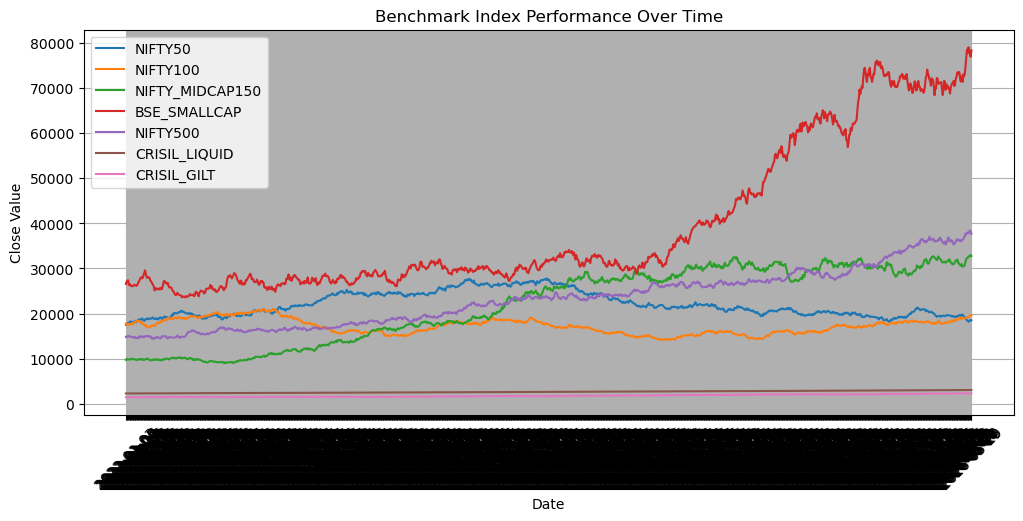

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for idx in ben_df['index_name'].unique():
    temp = ben_df[ben_df['index_name'] == idx]
    plt.plot(temp['date'], temp['close_value'], label=idx)

plt.legend()
plt.title("Benchmark Index Performance Over Time")
plt.xlabel("Date")
plt.ylabel("Close Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

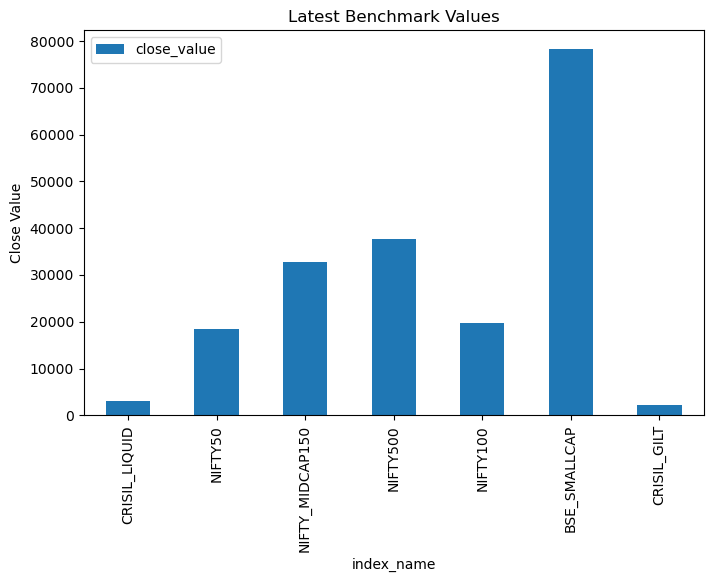

In [9]:
latest = ben_df.sort_values('date').groupby('index_name').tail(1)

latest.plot(
    x='index_name',
    y='close_value',
    kind='bar',
    figsize=(8,5)
)

plt.title("Latest Benchmark Values")
plt.ylabel("Close Value")
plt.show()

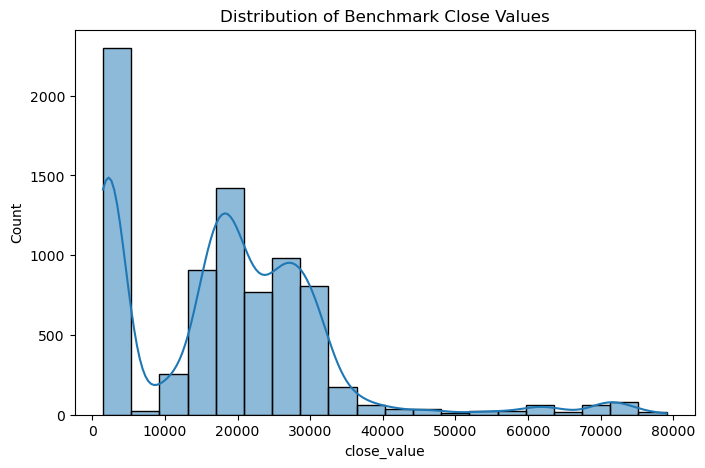

In [10]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    ben_df['close_value'],
    bins=20,
    kde=True
)

plt.title("Distribution of Benchmark Close Values")
plt.show()

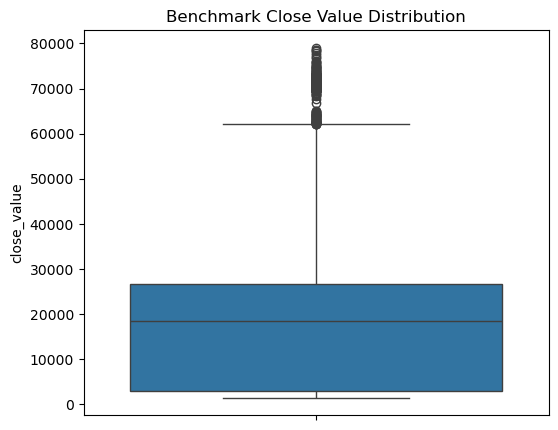

In [11]:
plt.figure(figsize=(6,5))

sns.boxplot(
    y=ben_df['close_value']
)

plt.title("Benchmark Close Value Distribution")
plt.show()

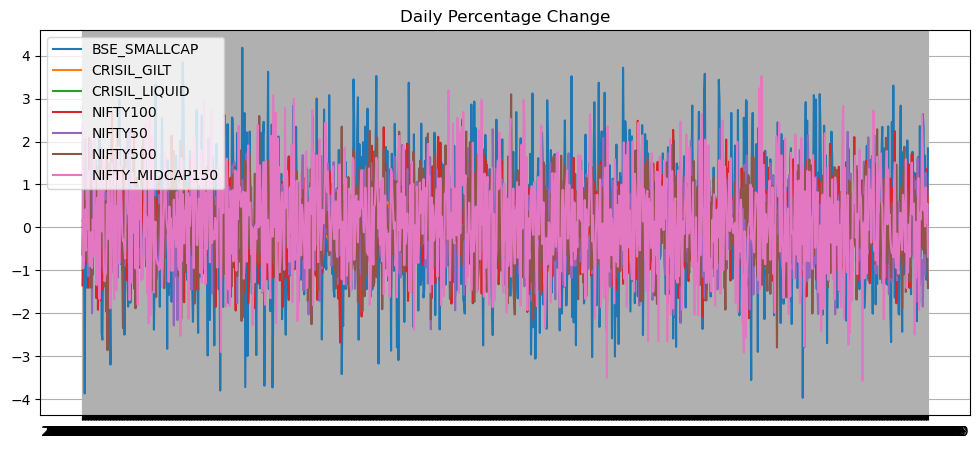

In [13]:
bench = ben_df.sort_values(['index_name','date'])

bench['daily_return'] = ben_df.groupby('index_name')['close_value'].pct_change()*100

plt.figure(figsize=(12,5))

for idx in bench['index_name'].unique():
    temp = bench[bench['index_name']==idx]
    plt.plot(temp['date'], temp['daily_return'], label=idx)

plt.legend()
plt.title("Daily Percentage Change")
plt.grid(True)
plt.show()

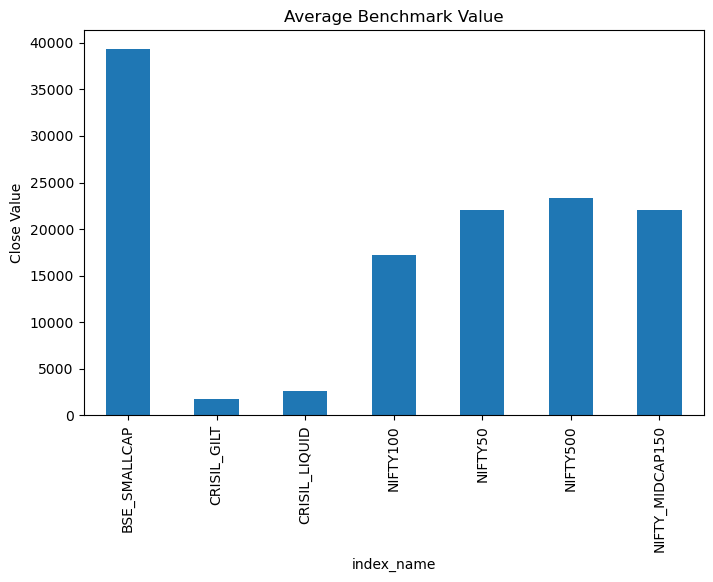

In [14]:
avg = ben_df.groupby('index_name')['close_value'].mean()

plt.figure(figsize=(8,5))
avg.plot(kind='bar')

plt.title("Average Benchmark Value")
plt.ylabel("Close Value")
plt.show()

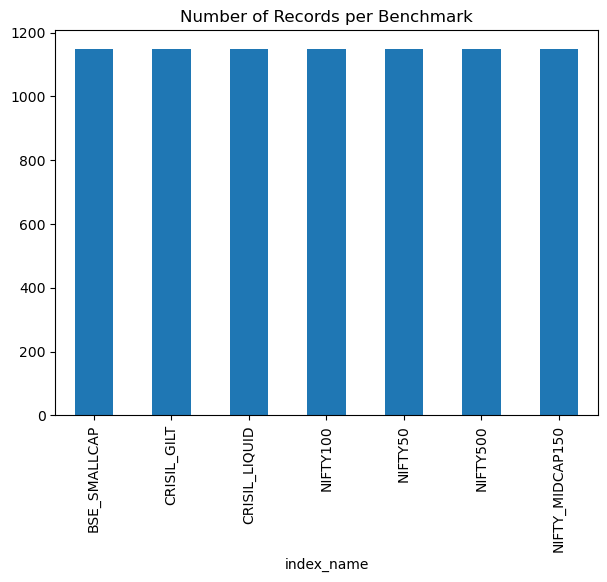

In [15]:
bench['index_name'].value_counts().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Number of Records per Benchmark")
plt.show()

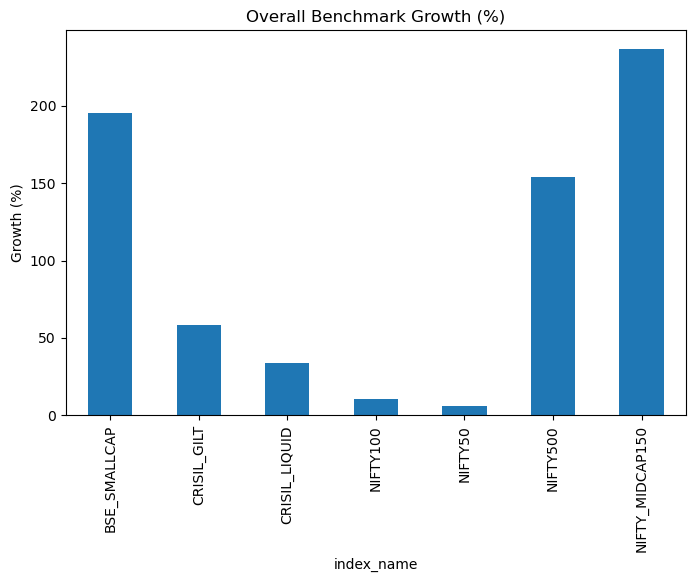

In [17]:
growth = ben_df.groupby('index_name').agg(
    Start=('close_value','first'),
    End=('close_value','last')
)

growth['Growth (%)'] = (
    (growth['End'] - growth['Start']) /
    growth['Start']
) * 100

growth['Growth (%)'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Overall Benchmark Growth (%)")
plt.ylabel("Growth (%)")
plt.show()